In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
train = pd.read_excel("/content/WLS_train_data.xlsx")

In [ ]:
Y_train = train[['Y']].values
X_train = train[['X']].values

In [ ]:
ones = np.ones((X_train.shape[0],1))
X_train = np.hstack((ones, X_train))

In [ ]:
sigma = train['Standar Deviation'].values
weights = 1 / (sigma**2)
W = np.diag(weights)

In [ ]:
beta_wls = np.linalg.inv(X_train.T @ W @ X_train) @ X_train.T @ W @ Y_train

beta_ols = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ Y_train

In [ ]:
print("Learned Parameters:")
print("OLS β (intercept, slope):", beta_ols.flatten())
print("WLS β (intercept, slope):", beta_wls.flatten())

Learned Parameters:
OLS β (intercept, slope): [0.09733629 0.36473142]
WLS β (intercept, slope): [0.1005584  0.34866921]


In [ ]:
test = pd.read_excel("/content/WLS Test_data.xlsx")
Y_test = test[['Y']].values
X_test = test[['X']].values
ones = np.ones((X_test.shape[0],1))
X_test = np.hstack((ones, X_test))

In [ ]:
Y_pred_wls_test = X_test @ beta_wls

Y_pred_ols_test = X_test @ beta_ols

res_wls_test = Y_test - Y_pred_wls_test

res_ols_test = Y_test - Y_pred_ols_test

In [ ]:
Y_pred_wls_train = X_train @ beta_wls

Y_pred_ols_train = X_train @ beta_ols

res_wls_train = Y_train - Y_pred_wls_train

res_ols_train = Y_train - Y_pred_ols_train

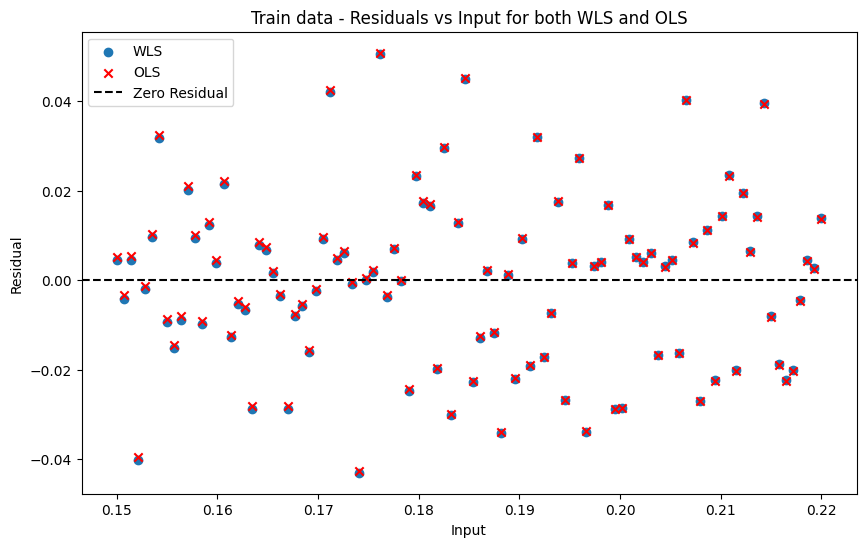

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(X_train[:,1], res_wls_train, color = '#1f77b4',label="WLS")
plt.scatter(X_train[:,1], res_ols_train, marker = 'x', color = 'red',label="OLS")
plt.axhline(0, linestyle='--', color='black', label='Zero Residual')

plt.xlabel("Input")
plt.ylabel("Residual")
plt.legend()
plt.title("Train data - Residuals vs Input for both WLS and OLS")
plt.show()

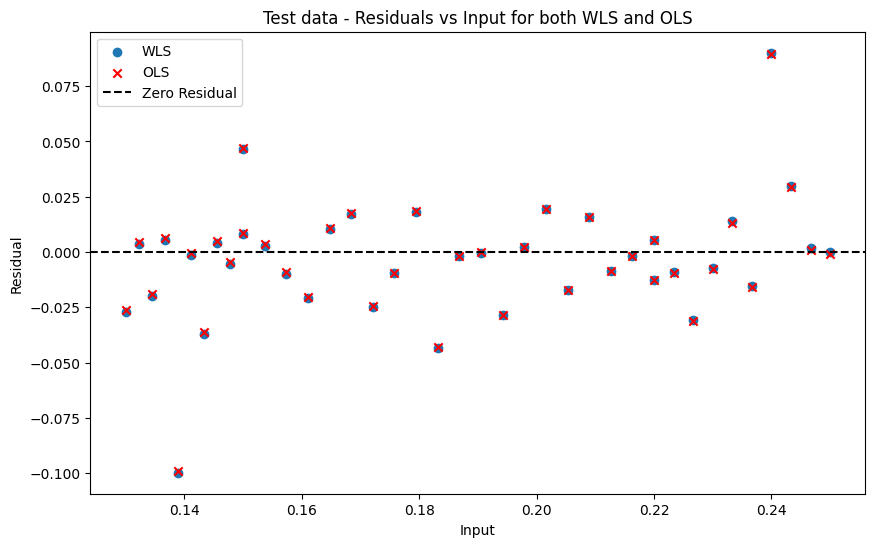

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(X_test[:,1], res_wls_test, color = '#1f77b4',label="WLS")
plt.scatter(X_test[:,1], res_ols_test, marker = 'x',color = 'red',label="OLS")
plt.axhline(0, linestyle='--', color='black', label='Zero Residual')

plt.xlabel("Input")
plt.ylabel("Residual")
plt.legend()
plt.title("Test data - Residuals vs Input for both WLS and OLS")
plt.show()

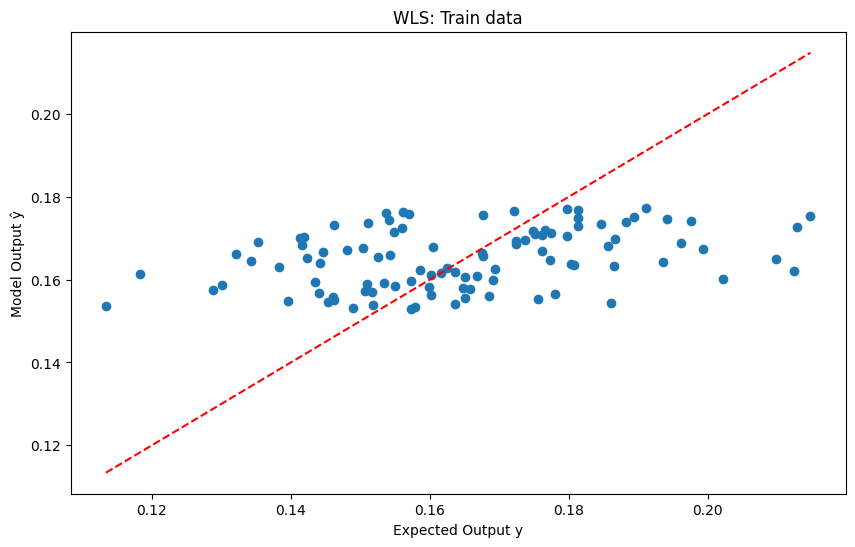

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(Y_train, Y_pred_wls_train)
plt.xlabel("Expected Output y")
plt.ylabel("Model Output ŷ")
plt.title("WLS: Train data")
plt.plot([min(Y_train), max(Y_train)],
         [min(Y_train), max(Y_train)],
         'r--')
plt.show()

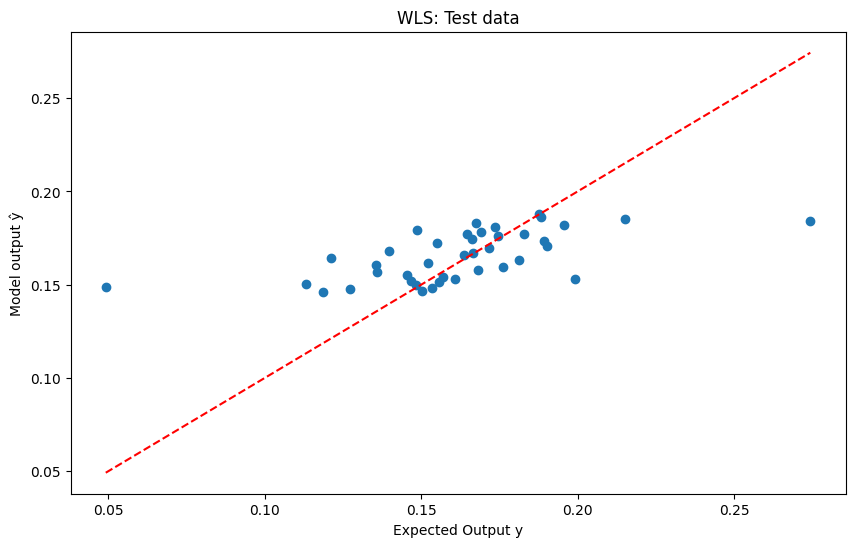

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(Y_test, Y_pred_wls_test)
plt.xlabel("Expected Output y")
plt.ylabel("Model output ŷ")
plt.title("WLS: Test data")
plt.plot([min(Y_test), max(Y_test)],
         [min(Y_test), max(Y_test)],
         'r--')
plt.show()

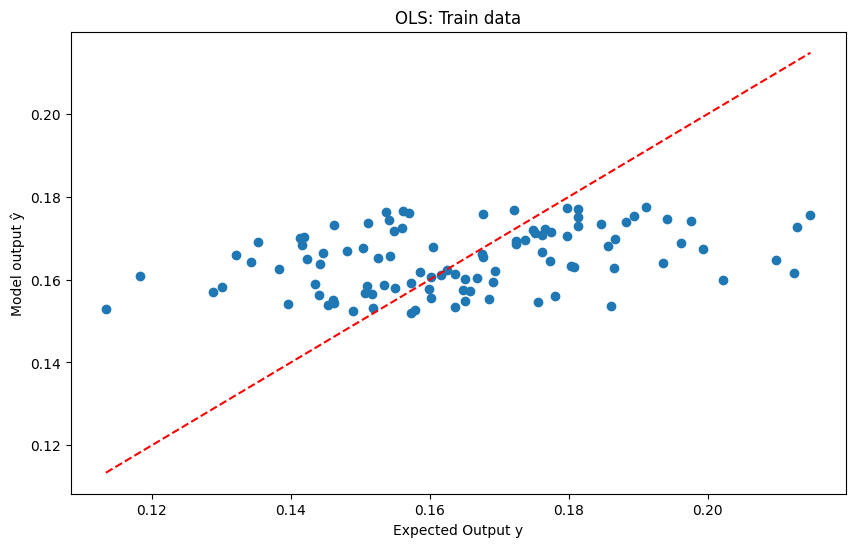

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(Y_train, Y_pred_ols_train)
plt.xlabel("Expected Output y")
plt.ylabel("Model output ŷ")
plt.title("OLS: Train data")
plt.plot([min(Y_train), max(Y_train)],
         [min(Y_train), max(Y_train)],
         'r--')
plt.show()

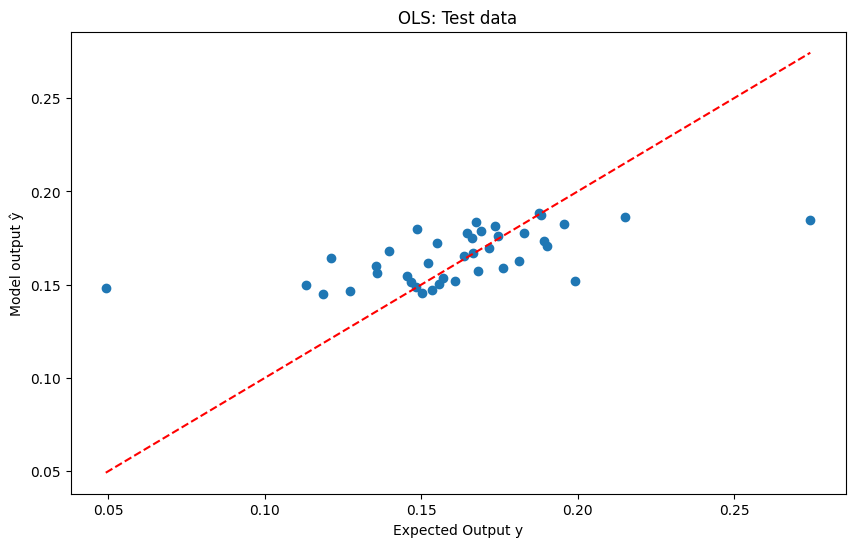

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(Y_test, Y_pred_ols_test)
plt.xlabel("Expected Output y")
plt.ylabel("Model output ŷ")
plt.title("OLS: Test data")
plt.plot([min(Y_test), max(Y_test)],
         [min(Y_test), max(Y_test)],
         'r--')
plt.show()

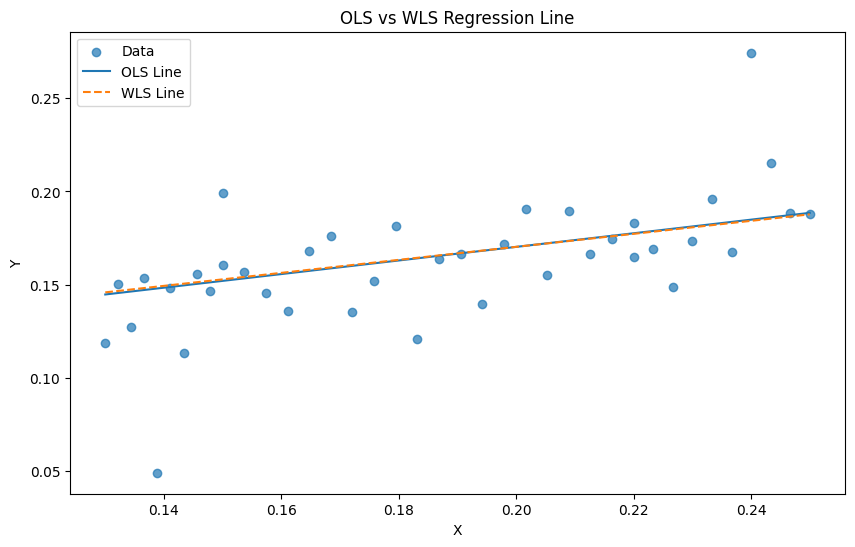

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(X_test[:,1], Y_test, alpha=0.7, label='Data')
plt.plot(X_test[:,1], Y_pred_ols_test, label='OLS Line')
plt.plot(X_test[:,1], Y_pred_wls_test, linestyle='--', label='WLS Line')
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.title("OLS vs WLS Regression Line")
plt.show()